# Real-data rPIE vs geometric MAGPIE

This notebook compares Pty-Chi rPIE with the geometric MAGPIE update on the chip dataset.


In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "common.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2


from chip.utils import (
    RealDataConfig,
    configure_ptychi_device,
    load_real_dataset,
    plot_real_data_overview,
    plot_real_loss_comparison,
    plot_real_object_comparison,
    plot_real_probe_comparison,
    print_real_dataset_summary,
    run_real_geometric_magpie,
    run_real_rpie,
    set_random_seed,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
cfg = RealDataConfig(
    num_epochs=240,
    batch_size=64,
    use_mps=True,
    fzp_defocus_m=-9e-4,
    intensity_floor=None,
    cutoff_radius_px=128,
    object_alpha=0.5,
    object_step_size=1.0,
    probe_alpha=1.0,
    probe_step_size=1.0,
    object_extra_pixels=50,
    print_residual_every=1,
)

device = configure_ptychi_device(cfg.use_mps)
set_random_seed(cfg.seed)

RPIE_RECONSTRUCTION_SEED = cfg.seed
MAGPIE_RECONSTRUCTION_SEED = cfg.seed + 1


data_shape: (812, 512, 512)
probe_shape: (512, 512)
position_shape: (812, 2)
max_fractional_position_px: 0.48777008056640625
mean_fractional_position_px: 0.2558145225048065
dx_m: 1.25921446015625e-08
wavelength_m: 1.23984193e-10


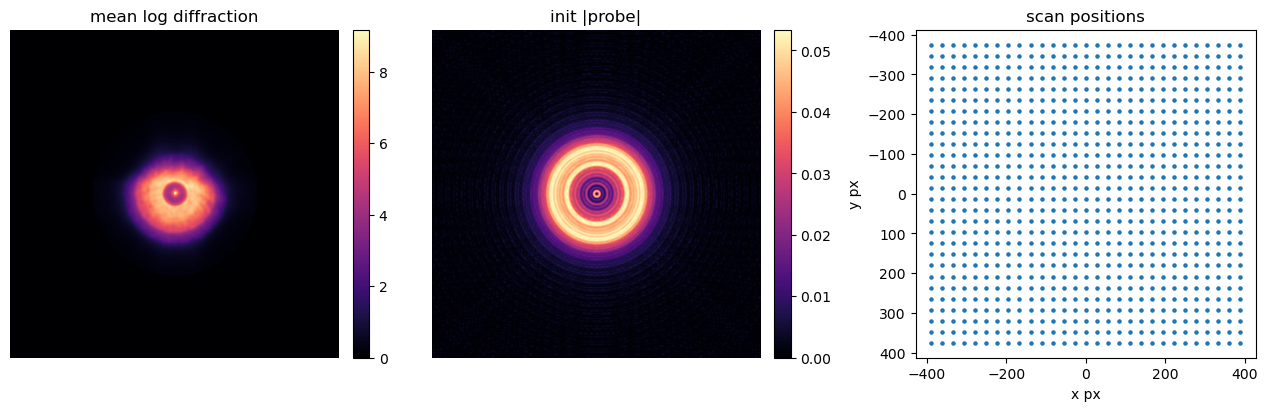

In [6]:
dataset = load_real_dataset(cfg)
print_real_dataset_summary(dataset)
plot_real_data_overview(dataset)


This notebook uses the shifted-probe subpixel convention. The object patches are extracted on the integer grid, and Pty-Chi constructs a batch of subpixel-shifted probes for each minibatch when the scan positions have fractional pixel offsets.

MAGPIE computes the local object geometric mean with the shifted probe for each scan position, fuses the object updates on the integer object grid, and adjoint-shifts the local probe updates back to the canonical probe frame before fusing. 

In [7]:
rpie = run_real_rpie(
    dataset,
    cfg,
    device,
    seed=RPIE_RECONSTRUCTION_SEED,
)


/Users/borongzhang/miniforge3/envs/magpie/lib/python3.11/site-packages/torch/utils/_device.py:116: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  return func(*args, **kwargs)


rPIE: iteration 1/240, residual 5.601784e+00
rPIE: iteration 2/240, residual 1.947244e+00
rPIE: iteration 3/240, residual 1.319002e+00
rPIE: iteration 4/240, residual 1.011989e+00
rPIE: iteration 5/240, residual 8.223965e-01
rPIE: iteration 6/240, residual 7.187328e-01
rPIE: iteration 7/240, residual 6.632907e-01
rPIE: iteration 8/240, residual 6.307968e-01
rPIE: iteration 9/240, residual 6.163282e-01
rPIE: iteration 10/240, residual 5.948696e-01
rPIE: iteration 11/240, residual 5.747622e-01
rPIE: iteration 12/240, residual 5.630080e-01
rPIE: iteration 13/240, residual 5.377386e-01
rPIE: iteration 14/240, residual 5.263582e-01
rPIE: iteration 15/240, residual 5.004332e-01
rPIE: iteration 16/240, residual 4.792587e-01
rPIE: iteration 17/240, residual 4.562653e-01
rPIE: iteration 18/240, residual 4.411828e-01
rPIE: iteration 19/240, residual 4.362631e-01
rPIE: iteration 20/240, residual 4.328758e-01
rPIE: iteration 21/240, residual 4.286111e-01
rPIE: iteration 22/240, residual 4.258038e-

In [8]:
geometric_magpie = run_real_geometric_magpie(
    dataset,
    cfg,
    device,
    seed=MAGPIE_RECONSTRUCTION_SEED,
)


MAGPIE: iteration 1/240, residual 3.017349e+00
MAGPIE: iteration 2/240, residual 6.364508e-01
MAGPIE: iteration 3/240, residual 5.639732e-01
MAGPIE: iteration 4/240, residual 5.347109e-01
MAGPIE: iteration 5/240, residual 5.191066e-01
MAGPIE: iteration 6/240, residual 5.074555e-01
MAGPIE: iteration 7/240, residual 4.976631e-01
MAGPIE: iteration 8/240, residual 4.920262e-01
MAGPIE: iteration 9/240, residual 4.845659e-01
MAGPIE: iteration 10/240, residual 4.791201e-01
MAGPIE: iteration 11/240, residual 4.729716e-01
MAGPIE: iteration 12/240, residual 4.694102e-01
MAGPIE: iteration 13/240, residual 4.631458e-01
MAGPIE: iteration 14/240, residual 4.599908e-01
MAGPIE: iteration 15/240, residual 4.539625e-01
MAGPIE: iteration 16/240, residual 4.507835e-01
MAGPIE: iteration 17/240, residual 4.466765e-01
MAGPIE: iteration 18/240, residual 4.441268e-01
MAGPIE: iteration 19/240, residual 4.403105e-01
MAGPIE: iteration 20/240, residual 4.371999e-01
MAGPIE: iteration 21/240, residual 4.332026e-01
M

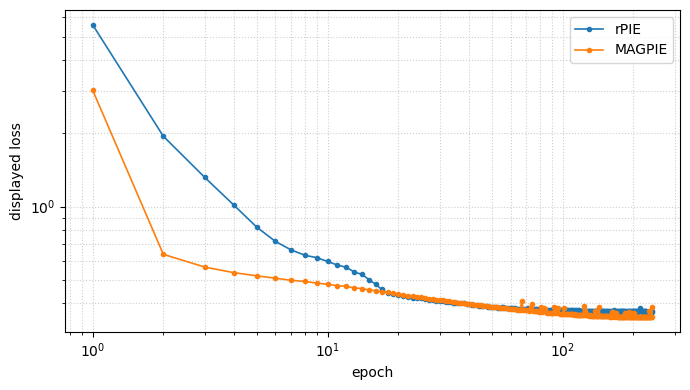

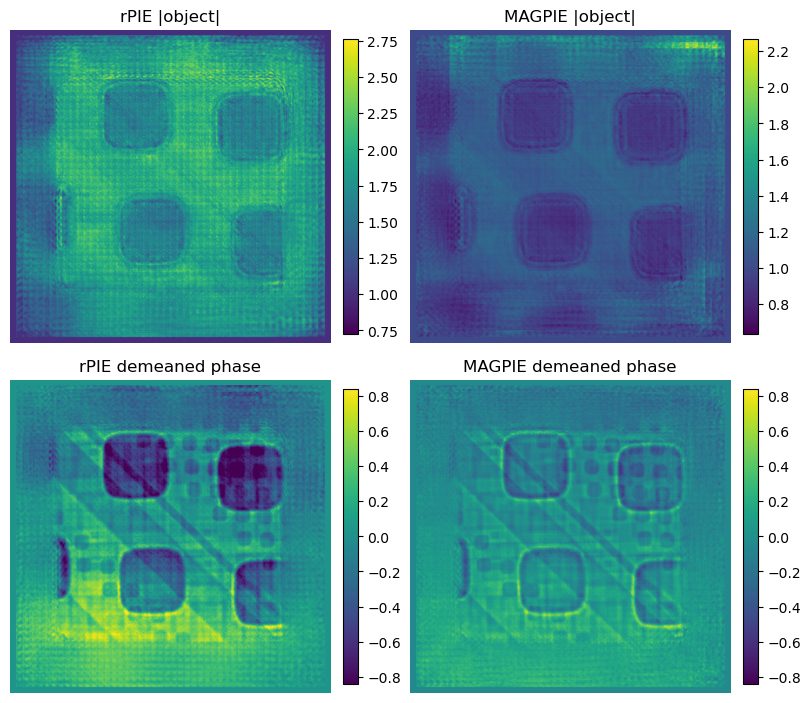

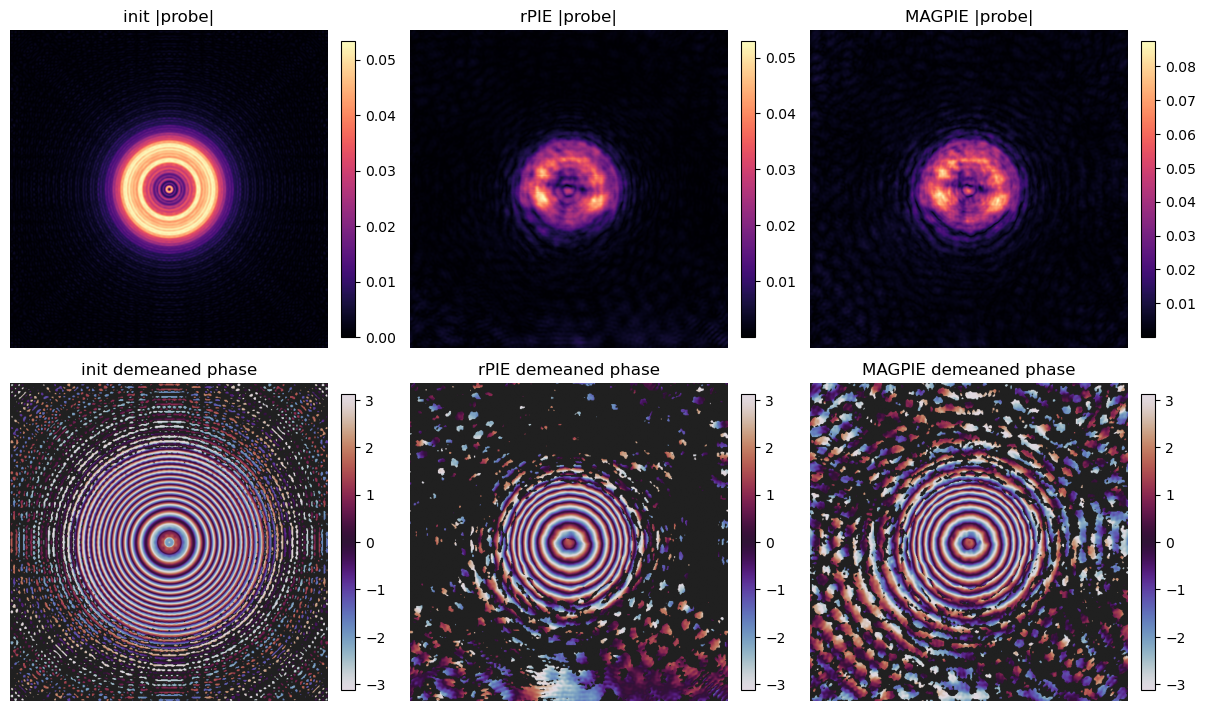

In [9]:
results = {
    "rPIE": rpie,
    "MAGPIE": geometric_magpie,
}

plot_real_loss_comparison({name: result.task for name, result in results.items()})
plot_real_object_comparison(results, phase_vlim_rad=None, phase_percentile=99.5)
plot_real_probe_comparison(dataset.probe_init, results, phase_vlim_rad=None, phase_percentile=99.5)


In [10]:
rpie_recon_obj = rpie.object
rpie_recon_probe = rpie.probe
magpie_recon_obj = geometric_magpie.object
magpie_recon_probe = geometric_magpie.probe
